In [6]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

## Objective:
The objective of this project is to analyze the factors affecting house prices and understand the relationships between different house features and price. The insights obtained from EDA will be used to build a Linear Regression model for house price prediction.

In [8]:
pf = pd.read_csv("../data/house_data.csv")
print(pf.head())

   area_sqft  bedrooms  bathrooms  stories  price_pkr
0        650         1          1        1    5200000
1        720         2          1        1    6100000
2        800         2          2        1    7200000
3        900         2          2        1    7900000
4        950         3          2        1    8500000


In [9]:
# Check dataset size
print(pf.shape)
# Check column names
print(pf.columns)
# Check data types
print(pf.dtypes)

(40, 5)
Index(['area_sqft', 'bedrooms', 'bathrooms', 'stories', 'price_pkr'], dtype='str')
area_sqft    int64
bedrooms     int64
bathrooms    int64
stories      int64
price_pkr    int64
dtype: object


In [10]:
# Get info
print(pf.info())
# Get Null values
print(pf.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area_sqft  40 non-null     int64
 1   bedrooms   40 non-null     int64
 2   bathrooms  40 non-null     int64
 3   stories    40 non-null     int64
 4   price_pkr  40 non-null     int64
dtypes: int64(5)
memory usage: 1.7 KB
None
area_sqft    0
bedrooms     0
bathrooms    0
stories      0
price_pkr    0
dtype: int64


The dataset contains 40 records and 5 columns,including 4 predictor variables and 1 target variable. There are no missing values or duplicate records, indicating that the dataset is clean and suitable for further analysis.

In [11]:
# Get basic statistics
print(pf.describe())

         area_sqft   bedrooms  bathrooms    stories     price_pkr
count    40.000000  40.000000    40.0000  40.000000  4.000000e+01
mean   1714.000000   3.625000     3.1750   1.775000  1.565250e+07
std     704.370241   1.125178     1.1522   0.422902  6.644141e+06
min     650.000000   1.000000     1.0000   1.000000  5.200000e+06
25%    1160.000000   3.000000     2.0000   2.000000  1.047500e+07
50%    1635.000000   4.000000     3.0000   2.000000  1.500000e+07
75%    2225.000000   4.250000     4.0000   2.000000  2.050000e+07
max    3150.000000   5.000000     5.0000   2.000000  2.880000e+07


In [12]:
# Duplicate rows check karo

pf.duplicated().sum()

np.int64(0)

The descriptive statistics provide an overview of the central tendency and distribution of house-related variables. The price variable shows considerable variation between the minimum and maximum house prices.

In [13]:
# Features aur target
X = pf[['area_sqft','bedrooms','bathrooms','stories']]
Y = pf[['price_pkr']]
print(X.shape)
print(Y.shape)

(40, 4)
(40, 1)


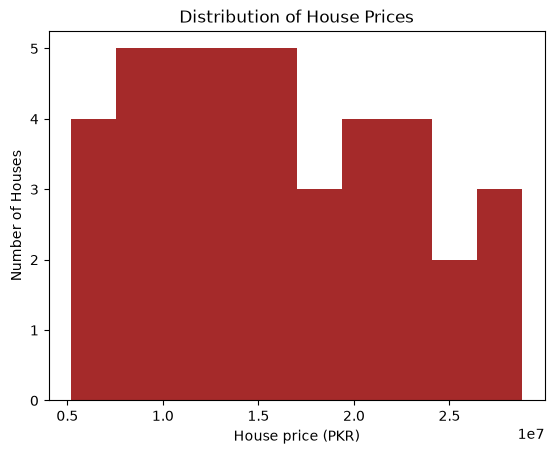

In [15]:
# Price distribution
plt.hist(pf['price_pkr'],bins=10,color='brown')
plt.xlabel("House price (PKR)")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

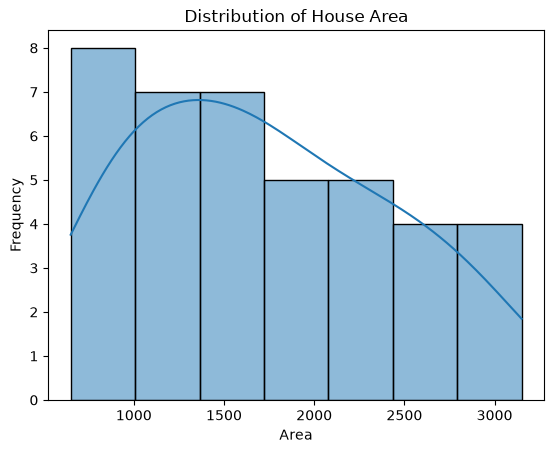

In [16]:
# Area distribution
sns.histplot(data=pf['area_sqft'],kde=True)
plt.title('Distribution of House Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()


Purpose: To understand how house prices are distributed in the dataset and whether prices are concentrated in a particular range.

Observation: The histogram shows that house prices vary across a broad range. More observations appear in the middle-to-lower price bands, while fewer houses appear toward the higher-price end. The distribution does not show one narrow, dominant price band.

Interpretation: House prices have noticeable variation in this dataset. We should inspect the numerical summary and potential outliers before deciding how to prepare the data for modeling.

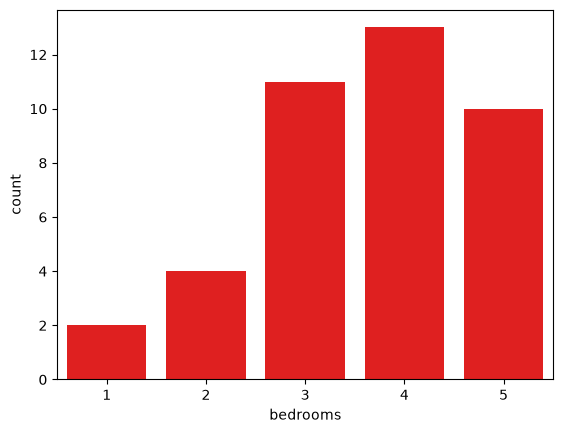

bedrooms
4    13
3    11
5    10
2     4
1     2
Name: count, dtype: int64


In [25]:
# Categorical-style feature distributions
sns.countplot(data= pf,
              x='bedrooms',
              color='Red'
             
)
plt.show()
# Bedroom count
print(pf['bedrooms'].value_counts())

## Bedroom Count Distribution

Observation: The bedroom-count distribution shows that houses with 4 bedrooms occur most frequently in the sample dataset.

Interpretation: Four-bedroom houses are the most common bedroom configuration in this sample. This describes the dataset’s composition; it does not necessarily represent the wider housing market.

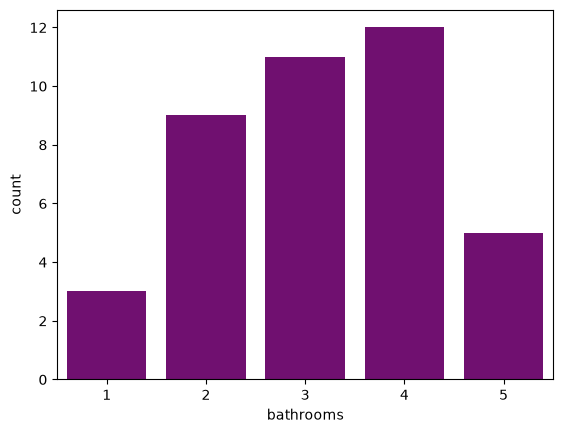

bathrooms
4    12
3    11
2     9
5     5
1     3
Name: count, dtype: int64


In [26]:
# Categorical-style feature distributions
sns.countplot(data= pf,
              x='bathrooms',
              color='Purple'
             
)
plt.show()
# Bedroom count
print(pf['bathrooms'].value_counts())

## Bathrooms Distribution:
 The count plot indicates that houses with 4 Bathrooms are the most frequent in the sample dataset. This describes the distribution of the available observations, not necessarily the wider housing market.

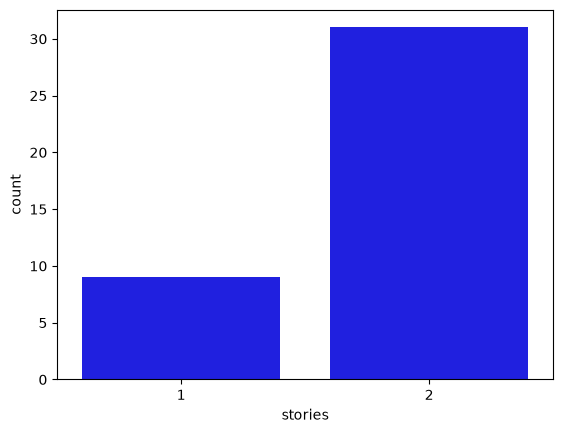

stories
2    31
1     9
Name: count, dtype: int64


In [28]:
sns.countplot(data= pf,
              x='stories',
              color='Blue'
             
)
plt.show()
# Bedroom count
print(pf['stories'].value_counts())


## Stories Distribution:
 
The count plot indicates that houses with 2 stories are the most frequent in the sample dataset. This describes the distribution of the available observations, not necessarily the wider housing market.

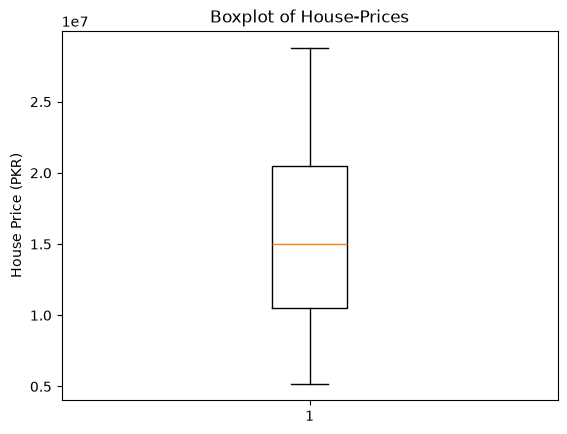

In [17]:
# Identify outlier
plt.boxplot(pf['price_pkr'])
plt.ylabel("House Price (PKR)")
plt.title("Boxplot of House-Prices")
plt.show()

## Outlier Analysis

Observation:
The boxplot does not show any visible outliers in the price_pkr variable. All observed house prices fall within the lower and upper whisker range.

Interpretation:
There is no strong evidence of extreme price values that need to be removed as outliers at this stage. Therefore, we will keep all house-price observations for further analysis.



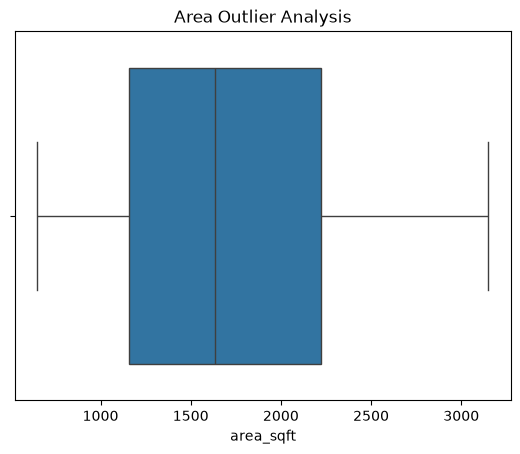

In [38]:
#Identify  Area outlier
sns.boxplot(x=pf['area_sqft'])
plt.title('Area Outlier Analysis')
plt.show()


## Area Outlier Analysis:

The boxplot of house area does not show any significant outliers. All observations lie within the whisker boundaries, indicating that there are no extreme area values according to the IQR method.

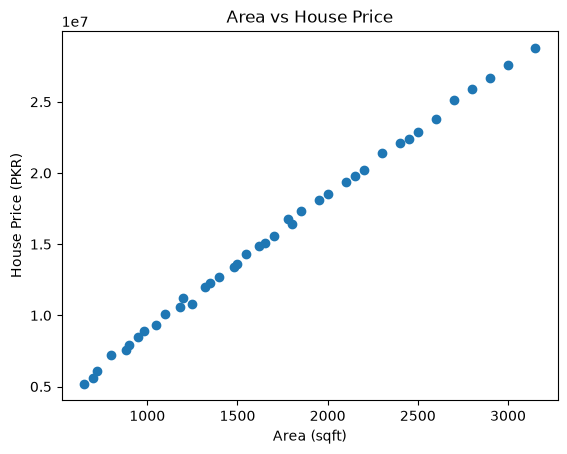

In [18]:
# Relation of area with price
plt.scatter(pf["area_sqft"], pf["price_pkr"])

plt.xlabel("Area (sqft)")
plt.ylabel("House Price (PKR)")
plt.title("Area vs House Price")

plt.show()

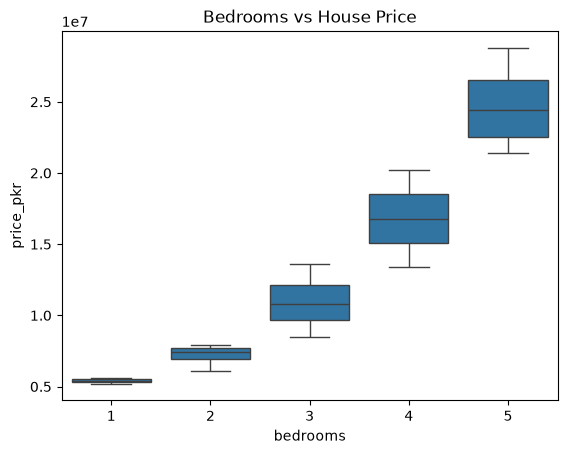

In [30]:
# Bedrooms vs Price
sns.boxplot(data=pf,x='bedrooms',y='price_pkr')
plt.title('Bedrooms vs House Price')
plt.show()

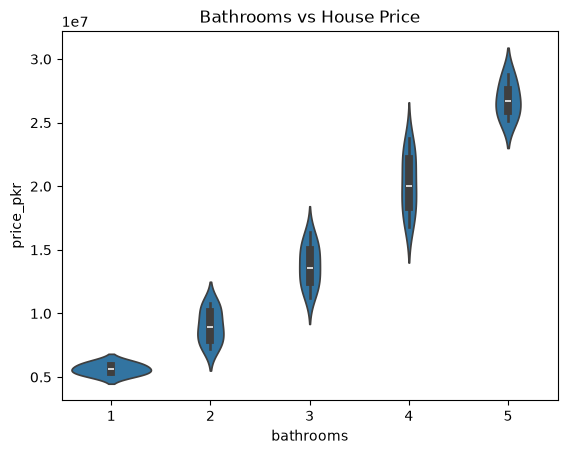

In [32]:
# Bathrooms vs Price
sns.violinplot(data=pf,x='bathrooms',y='price_pkr')
plt.title('Bathrooms vs House Price')
plt.show()

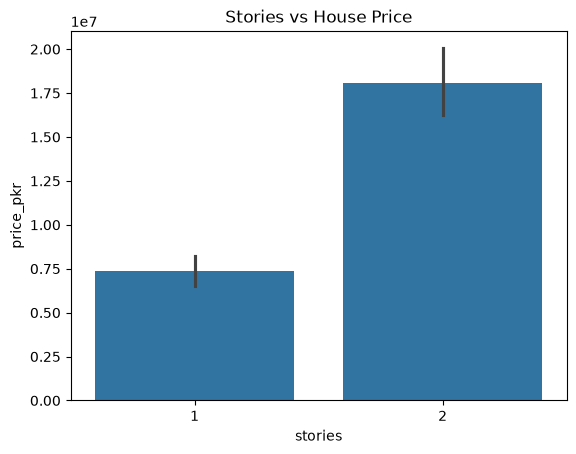

In [41]:
# Stories vs Price
sns.barplot(data=pf,x='stories',y='price_pkr')
plt.title('Stories vs House Price')
plt.show()

In [19]:
numeric_pf = pf[['area_sqft','bedrooms', 'bathrooms','stories','price_pkr']]
numeric_pf.corr()

,area_sqft,bedrooms,bathrooms,stories,price_pkr
area_sqft,1.000000,0.924646,0.952627,0.671068,0.999431
bedrooms,0.924646,1.000000,0.902380,0.734194,0.931162
bathrooms,0.952627,0.902380,1.000000,0.714344,0.960051
stories,0.671068,0.734194,0.714344,1.000000,0.680511
price_pkr,0.999431,0.931162,0.960051,0.680511,1.000000


## Correlation Analysis

1. Relationship between area and house price
The correlation coefficient between area_sqft and price_pkr is 0.999431, indicating an almost perfect positive linear relationship in this dataset. This means that houses with larger areas tend to have higher prices in the sample.

2. Relationship between stories and house price
Among the listed features, stories has the weakest positive correlation with price_pkr, with a coefficient of 0.680511. This indicates a positive relationship, but it is weaker than the relationships observed for area, bedrooms, and bathrooms.

3. Correlation among input features
The input features are also strongly correlated with one another. For example, area_sqft and bathrooms have a correlation coefficient of 0.952627. Such high correlations among input features may be relevant when interpreting the trained model.

4. Interpretation of correlation
Correlation measures the strength and direction of the linear association between two numeric variables. It does not establish that one variable causes changes in another.

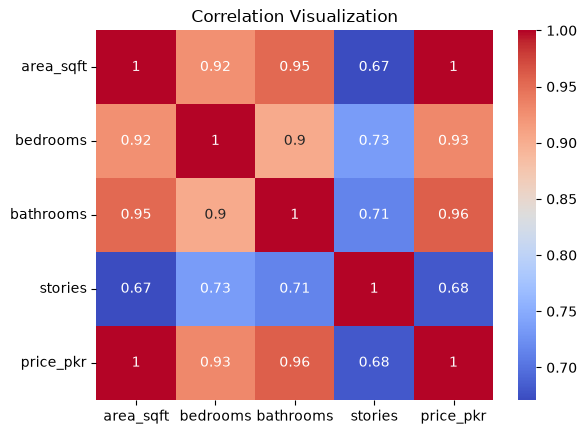

In [47]:
# Heatmap to show correlation
corr= pf.corr(numeric_only=True)
sns.heatmap(
  corr,
  annot=True,cmap='coolwarm'
)
plt.title('Correlation Visualization')
plt.show()


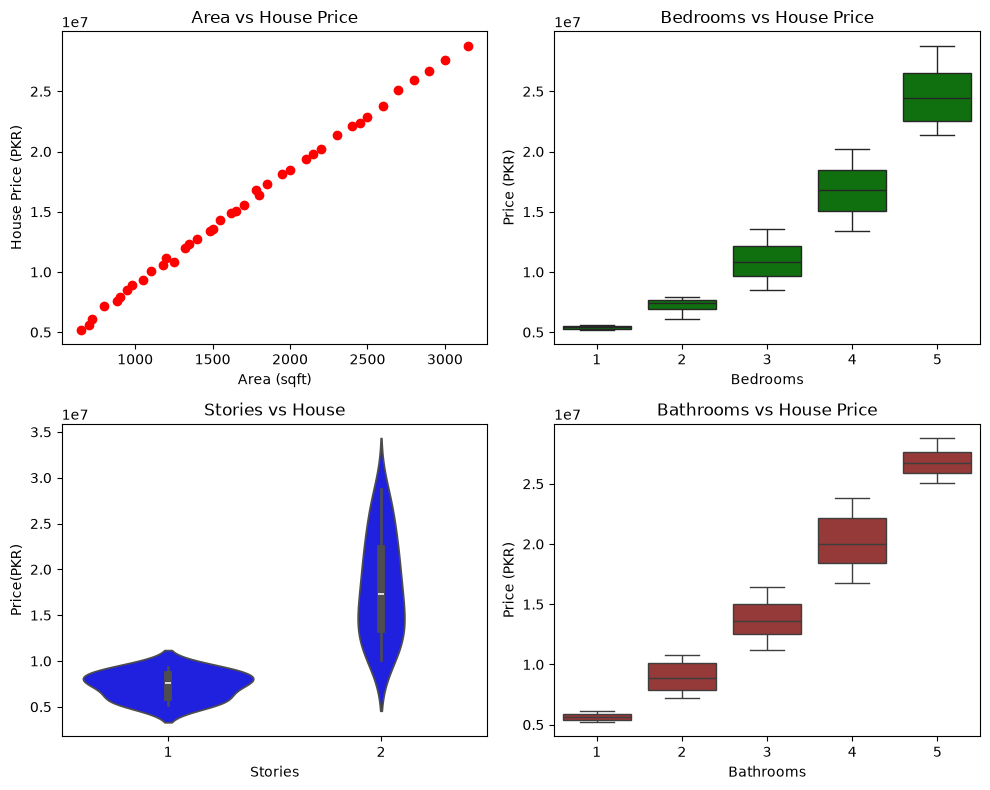

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Area Vs House price 
axes[0, 0].scatter(pf["area_sqft"], pf["price_pkr"], color='r')
axes[0, 0].set_title('Area vs House Price')
axes[0, 0].set_xlabel('Area (sqft)')
axes[0, 0].set_ylabel('House Price (PKR)')


# 2. Bedrooms vs House Price
sns.boxplot(data=pf,x='bedrooms',y='price_pkr',ax=axes[0,1],color='Green')
axes[0, 1].set_title('Bedrooms vs House Price')
axes[0, 1].set_xlabel('Bedrooms')
axes[0, 1].set_ylabel('Price (PKR)')


# 3. stories vs House Price
sns.violinplot(data=pf, x='stories',y='price_pkr' ,color='blue', ax=axes[1, 0])
axes[1, 0].set_title('Stories vs House')
axes[1, 0].set_xlabel('Stories')
axes[1, 0].set_ylabel('Price(PKR)')

# 4. Bathroom vs House Price
sns.boxplot(data=pf,x='bathrooms',y='price_pkr',ax=axes[1,1],color='brown')
axes[1, 1].set_title('Bathrooms vs House Price')
axes[1, 1].set_xlabel('Bathrooms')
axes[1, 1].set_ylabel('Price (PKR)')

plt.tight_layout()
plt.show()

## Key Findings 


The dataset contains 40 records and 5 columns.
No missing values or duplicate records were detected.
Four-bedroom houses are the most frequent in the dataset.
Two-story houses are the most frequent story configuration.
No significant outliers were identified in price_pkr or area_sqft.
area_sqft has an extremely strong positive correlation with price_pkr (r = 0.999431).
Bedrooms and bathrooms also show strong positive relationships with house price.
Stories has the weakest positive correlation with price among the selected predictors (r = 0.680511).
Some predictor variables are highly correlated with each other, indicating potential multicollinearity.

## Exploratory Data Analysis — Conclusion


The exploratory analysis shows that house price has strong linear relationships with several house features, particularly area. The dataset contains no missing values, duplicate records, or significant outliers requiring removal. Based on these findings, the selected features can be used to develop a Linear Regression model for house price prediction. The dataset will now be divided into training and testing sets to evaluate the model's predictive performance.

## Model Development

After completing the Exploratory Data Analysis, the next step is to develop a Linear Regression model to predict house prices.

The EDA showed that `area_sqft`, `bedrooms`, `bathrooms`, and `stories` have positive relationships with `price_pkr`. These variables will therefore be used as predictor features, while `price_pkr` will be used as the target variable.

The modeling process will include:
1. Feature and target selection
2. Train-test split
3. Model training
4. Price prediction
5. Model evaluation

## 11.1 Feature and Target Selection

The input features (X) are `area_sqft`, `bedrooms`, `bathrooms`, and `stories`. The target variable (y) is `price_pkr`.

In [50]:
X = pf[['area_sqft', 'bedrooms', 'bathrooms', 'stories']]
Y = pf['price_pkr']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (40, 4)
Target shape: (40,)


## 11.2 Train-Test Split

The dataset will be divided into training and testing sets. 80% of the data will be used for training the model, while 20% will be reserved for testing its predictive performance.

In [51]:
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", Y_train.shape)
print("Testing target:", Y_test.shape)

Training features: (32, 4)
Testing features: (8, 4)
Training target: (32,)
Testing target: (8,)


## 11.3 Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict a continuous target variable.

In this project, the model will learn the relationship between the house features (`area_sqft`, `bedrooms`, `bathrooms`, and `stories`) and the target variable (`price_pkr`).

The model will be trained using the training dataset and later used to predict house prices for unseen test data.

In [57]:
# Linear regression Model

model = LinearRegression()


## Model Training
The model was trained using 80% of the dataset.

In [59]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 8458.81,224660.86,412479.78,-25198.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['area_sqft','bedrooms','bathrooms','stories']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.325e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## Price Prediction

The trained model was used to predict house prices for the test dataset.

In [60]:
y_pred = model.predict(X_test)

print(y_pred)

[19329153.65892801 17214451.86455259 16379031.72985341 25887459.31845813
  8577103.60080144 14264329.93547798 16622335.36212746 26733340.0362083 ]


## 11.6 Model Evaluation

Mean Squared Error (MSE) is used to evaluate the performance of the Linear Regression model. It calculates the average squared difference between the actual house prices and the predicted house prices.

A lower MSE indicates that the predicted values are closer to the actual values.

In [67]:
# Calculate Mean Sqaure Error
mse = mean_squared_error(Y_test,y_pred)
print("Mean Squared Error:", mse)
# Calculate RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:" ,rmse)
# Calculate R sqaure
r2 = r2_score(Y_test,y_pred)
print("R² score :", r2)

Mean Squared Error: 6603528111.574461
Root Mean Squared Error: 81262.09517096185
R² score : 0.9997872221247586


### Model Evaluation Results

The Linear Regression model achieved an R² score of 0.999787, indicating that approximately 99.98% of the variation in house prices in the test set is explained by the selected features.

The model obtained an RMSE of approximately 81,262 PKR, representing the typical magnitude of prediction error on the price scale. The Mean Squared Error (MSE) was 6,603,528,111.57.

Overall, the model shows a very strong fit on this test set. However, the results are based on only 40 observations and should not be assumed to represent the performance of the model on a larger or different housing dataset.

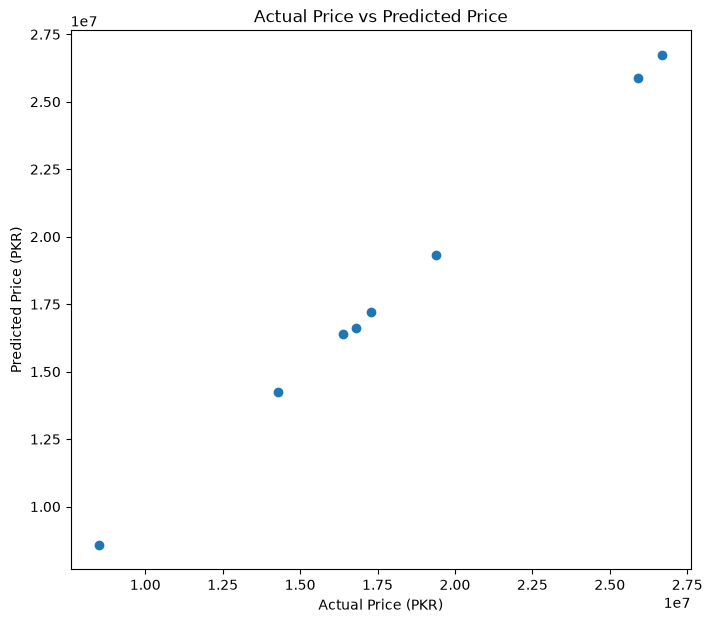

In [68]:
# 11.7 Actual Price vs Predicted Price
plt.figure(figsize=(8,7))
plt.scatter(Y_test,y_pred)
plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title("Actual Price vs Predicted Price")
plt.show()

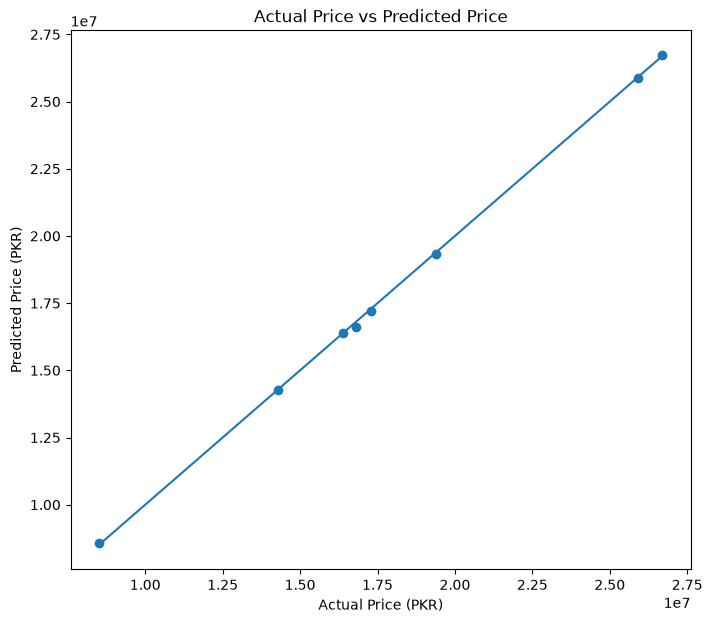

In [71]:
# Fit Linear regesstion line
plt.figure(figsize=(8,7))
plt.scatter(Y_test,y_pred)
plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title("Actual Price vs Predicted Price")

# Perfect prediction line
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()])

plt.show()

### Actual Price vs Predicted Price

The Actual Price vs Predicted Price plot is used to visually evaluate the performance of the Linear Regression model. The x-axis represents the actual house prices, while the y-axis represents the predicted prices.

Most of the data points lie very close to the diagonal reference line, which represents perfect predictions. This indicates that the predicted house prices are very close to the actual prices for the test dataset. The visualization is consistent with the high R² score of 0.999787 obtained during model evaluation.

### 11.8 Residual Analysis

Residual analysis is used to examine the errors made by the Linear Regression model. A residual represents the difference between the actual price and the predicted price.

Residuals are calculated using the following formula:

Residual = Actual Price - Predicted Price

Residual analysis helps determine whether the model errors are randomly distributed and whether any systematic pattern exists in the predictions.

In [72]:
# 11.8 Residual Analysis ====== R = Actual data - predicated data
ResidualAna = Y_test-y_pred
print(ResidualAna)

19     70846.341072
16     85548.135447
15     20968.270147
26     12540.681542
4     -77103.600801
12     35670.064522
37    177664.637873
27    -33340.036208
Name: price_pkr, dtype: float64


 ## Actual Residual Plot

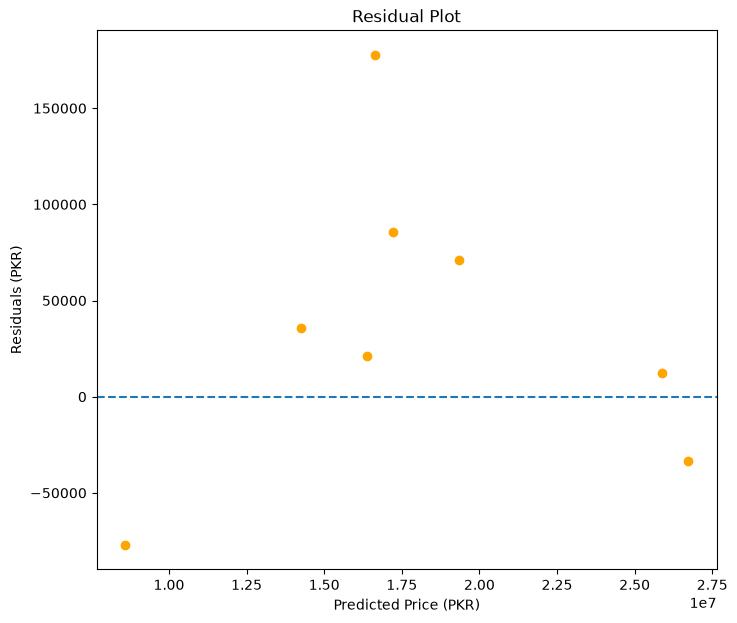

In [73]:
plt.figure(figsize=(8,7))
plt.scatter(y_pred,ResidualAna ,color='orange')
plt.axhline(y=0,linestyle='--')

plt.xlabel("Predicted Price (PKR)")
plt.ylabel("Residuals (PKR)")
plt.title("Residual Plot")

plt.show()


### Residual Analysis

The residual plot shows the difference between actual and predicted house prices. The residuals are plotted against the predicted prices, with the horizontal zero line representing perfect predictions.

Most residuals are distributed around the zero line, with both positive and negative errors. No strong systematic pattern or clear curve is visible in the residual plot. However, one observation has a relatively larger positive residual of approximately 177,665 PKR.

Overall, the residual plot does not show a strong visible pattern in the test data. Since the test set contains only 8 observations, the residual analysis should be interpreted with caution.

In [75]:
# 11.9 Final Model Interpretation
print("Intercept:",model.intercept_)

print("\nCoefficients:")
for feature,coefficient in zip(X.columns,model.coef_):
     print(feature, ":", coefficient)

Intercept: -932506.7407344412

Coefficients:
area_sqft : 8458.807177501716
bedrooms : 224660.859454826
bathrooms : 412479.77582408977
stories : -25198.60710340654


### 11.9 Final Model Interpretation

The Linear Regression model uses four predictor variables: area_sqft, bedrooms, bathrooms, and stories.

The coefficient for area_sqft is 8458.81, indicating that, while keeping the other selected features constant, a one-unit increase in area is associated with an increase of approximately 8,459 PKR in the predicted house price.

The coefficients for bedrooms and bathrooms are also positive, with values of 224,660.86 and 412,479.78 respectively. This indicates positive partial associations with the predicted house price when the other variables are held constant.

The coefficient for stories is -25,198.61. Although stories has a positive correlation with price in the EDA, its regression coefficient is negative when the other predictors are included simultaneously. This may be related to the strong correlations among some predictor variables, so the coefficient should not be interpreted as evidence that additional stories directly reduce house prices.

The model intercept is -932,506.74. The intercept is the predicted price when all predictor values are zero and has limited practical interpretation for this dataset.

## 11.10 Predicting the Price of a New House

In [82]:
# 11.10 New House Price Prediction
new_house = pd.DataFrame({
    'area_sqft': [820],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2]
})
predicted_price = model.predict(new_house)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 8089400.695901725


### 11.10 New House Price Prediction

The trained Linear Regression model was used to predict the price of a new house based on its features. For a house with 820 square feet of area, 4 bedrooms, 3 bathrooms, and 2 stories, the model predicted a price of approximately 8,089,401 PKR.

This demonstrates how the trained model can be used to estimate the price of a house from its input features.

## 11.11 Final Model Summary

A Linear Regression model was developed to predict house prices using four predictor variables: `area_sqft`, `bedrooms`, `bathrooms`, and `stories`. The dataset was divided into 80% training data and 20% testing data.

The model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The model achieved the following results:

- Mean Squared Error (MSE): 6,603,528,111.57
- Root Mean Squared Error (RMSE): 81,262.10 PKR
- R² Score: 0.999787 (approximately 99.98%)

The Actual Price vs Predicted Price plot showed that most predictions were close to the actual prices. The residual plot also showed residuals distributed around the zero line without a strong visible systematic pattern.

The trained model was also used to predict the price of a new house with 820 sqft area, 4 bedrooms, 3 bathrooms, and 2 stories. The predicted price was approximately 8,089,401 PKR.

# 12. Final Conclusion

This project focused on analyzing house price data and developing a Linear Regression model for house price prediction. The dataset contained 40 observations and 5 columns, including four predictor variables and one target variable.

The Exploratory Data Analysis showed that the dataset contained no missing values or duplicate records. The analysis also showed strong positive relationships between house price and several features, particularly `area_sqft`, which had a correlation of 0.999431 with `price_pkr`.

A Linear Regression model was developed using `area_sqft`, `bedrooms`, `bathrooms`, and `stories` as predictor variables. The model achieved an R² score of 0.999787 on the test set, with an RMSE of approximately 81,262 PKR. The Actual Price vs Predicted Price plot showed that most predictions were close to the actual prices, while the residual analysis did not show a strong visible systematic pattern.

The model was also used to predict the price of a new house based on its features. For a house with 820 sqft area, 4 bedrooms, 3 bathrooms, and 2 stories, the predicted price was approximately 8,089,401 PKR.

Overall, this project demonstrates the complete machine learning workflow, including data exploration, data quality checking, feature selection, train-test splitting, model training, prediction, evaluation, visualization, and prediction for new data. Since the dataset contains only 40 observations, the model's performance should be interpreted within the context of this dataset and may not generalize to larger or different housing datasets.